In [2]:
import kagglehub
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os

# --- 0. DOWNLOAD DATASET ---
# This downloads the latest version of the PlantVillage dataset
path = kagglehub.dataset_download("emmarex/plantdisease")
print("Path to dataset files:", path)

# Note: PlantVillage often downloads as "PlantVillage" or contains a "PlantVillage" subfolder.
# We will check if there is a subfolder to avoid errors.
dataset_dir = path
if "PlantVillage" in os.listdir(path):
    dataset_dir = os.path.join(path, "PlantVillage")

# --- 1. DEFINE CONSTANTS ---
IMAGE_SIZE = 256
BATCH_SIZE = 32
CHANNELS = 3
EPOCHS = 10 # Reduced for demonstration, change to 25 for full training

# --- 2. DATA PREPROCESSING AND AUGMENTATION ---
train_datagen = ImageDataGenerator(
    rescale=1./255,            # Normalize pixel values
    rotation_range=20,         # Data augmentation
    horizontal_flip=True,
    zoom_range=0.2,
    validation_split=0.2       # 20% for validation
)

# Training Generator
train_generator = train_datagen.flow_from_directory(
    dataset_dir,               # Using the kagglehub path variable
    target_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

# Validation Generator
validation_generator = train_datagen.flow_from_directory(
    dataset_dir,               # Using the kagglehub path variable
    target_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

# --- 3. DESIGN CNN ARCHITECTURE ---
model = models.Sequential([
    # First Convolutional block
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(IMAGE_SIZE, IMAGE_SIZE, CHANNELS)),
    layers.MaxPooling2D((2, 2)),

    # Second Convolutional block
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Third Convolutional block
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Flattening and Dense Layers
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),      # Prevents overfitting

    # Output layer
    layers.Dense(train_generator.num_classes, activation='softmax')
])

# --- 4. COMPILE MODEL ---
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# --- 5. TRAIN MODEL ---
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // BATCH_SIZE
)

# --- 6. SAVE MODEL ---
model.save("plant_disease_model.h5")
print("Model saved as plant_disease_model.h5")

Using Colab cache for faster access to the 'plantdisease' dataset.
Path to dataset files: /kaggle/input/plantdisease
Found 16516 images belonging to 15 classes.
Found 4122 images belonging to 15 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 417s 791ms/step - accuracy: 0.3832 - loss: 1.9294 - val_accuracy: 0.6392 - val_loss: 1.1108
Epoch 2/10
  1/516 ━━━━━━━━━━━━━━━━━━━━ 49s 95ms/step - accuracy: 0.5000 - loss: 1.3953

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


516/516 ━━━━━━━━━━━━━━━━━━━━ 63s 122ms/step - accuracy: 0.5000 - loss: 1.3953 - val_accuracy: 0.6509 - val_loss: 1.0999
Epoch 3/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 332s 644ms/step - accuracy: 0.5886 - loss: 1.2538 - val_accuracy: 0.7505 - val_loss: 0.8168
Epoch 4/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 64s 123ms/step - accuracy: 0.5938 - loss: 1.0143 - val_accuracy: 0.7471 - val_loss: 0.8433
Epoch 5/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 329s 637ms/step - accuracy: 0.6552 - loss: 1.0412 - val_accuracy: 0.7703 - val_loss: 0.6748
Epoch 6/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 61s 119ms/step - accuracy: 0.6562 - loss: 0.9392 - val_accuracy: 0.7710 - val_loss: 0.6753
Epoch 7/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 330s 637ms/step - accuracy: 0.6984 - loss: 0.9052 - val_accuracy: 0.7871 - val_loss: 0.6174
Epoch 8/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 63s 121ms/step - accuracy: 0.6875 - loss: 0.9161 - val_accuracy: 0.8074 - val_loss: 0.5983
Epoch 9/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 328s 636ms/step - accuracy: 0.7202 - loss: 0.8339 -

Model saved as plant_disease_model.h5


In [3]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

# 1. LOAD THE TRAINED MODEL
model = tf.keras.models.load_model('plant_disease_model.h5')

# 2. DEFINE THE PREDICTION FUNCTION
def predict_plant_disease(img_path):
    # Load and resize image to match model input (256x256)
    img = image.load_img(img_path, target_size=(256, 256))

    # Convert image to array and normalize (rescale by 1/255)
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) # Add batch dimension
    img_array /= 255.0 # Crucial: Must match training normalization

    # Perform prediction
    predictions = model.predict(img_array)

    # Get the class with the highest probability
    predicted_class_idx = np.argmax(predictions[0])
    confidence = np.max(predictions[0])

    # Get class names from the generator (if available in current session)
    # Otherwise, you would use a manual list of labels
    try:
        class_names = list(train_generator.class_indices.keys())
        result = class_names[predicted_class_idx]
    except NameError:
        result = f"Class Index: {predicted_class_idx}"

    # Visualize the image and result
    plt.imshow(img)
    plt.title(f"Prediction: {result}\nConfidence: {confidence*100:.2f}%")
    plt.axis('off')
    plt.show()

    return result, confidence

# 3. RUN PREDICTION
# Replace 'test_leaf.jpg' with the path to a real image in your folder
# result, score = predict_plant_disease('test_leaf.jpg')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


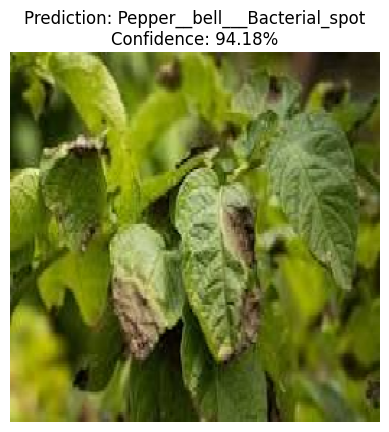

In [5]:
score = predict_plant_disease('/content/potato die.jpg')